# Setup

In [1]:
import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

import tensorflow as tf
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from geexhp import datavis

datavis.configure_matplotlib()

2026-04-09 13:53:46.725133: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-09 13:53:46.727042: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-09 13:53:46.735319: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-09 13:53:46.754436: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775753626.784058  625272 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775753626.79

In [2]:
uv_b = np.array(
    [
        0.2,
        0.22857143,
        0.26122449,
        0.29854227,
        0.34119117,
        0.38993277,
        0.44563745,
        0.50929994,
    ]
)
vis_b = np.array(
    [
        0.515,
        0.51867857,
        0.52238342,
        0.52611473,
        0.52987269,
        0.5336575,
        0.53746934,
        0.5413084,
        0.54517489,
        0.549069,
        0.55299092,
        0.55694085,
        0.560919,
        0.56492557,
        0.56896075,
        0.57302475,
        0.57711779,
        0.58124006,
        0.58539177,
        0.58957314,
        0.59378438,
        0.5980257,
        0.60229731,
        0.60659943,
        0.61093229,
        0.61529609,
        0.61969106,
        0.62411742,
        0.62857541,
        0.63306523,
        0.63758712,
        0.64214132,
        0.64672804,
        0.65134753,
        0.65600001,
        0.66068572,
        0.66540491,
        0.6701578,
        0.67494464,
        0.67976568,
        0.68462114,
        0.6895113,
        0.69443638,
        0.69939664,
        0.70439233,
        0.7094237,
        0.71449101,
        0.71959452,
        0.72473448,
        0.72991116,
        0.73512481,
        0.7403757,
        0.7456641,
        0.75099027,
        0.75635448,
        0.76175702,
        0.76719814,
        0.77267812,
        0.77819725,
        0.78375581,
        0.78935406,
        0.7949923,
        0.80067082,
        0.8063899,
        0.81214983,
        0.8179509,
        0.8237934,
        0.82967764,
        0.83560391,
        0.84157251,
        0.84758374,
        0.85363791,
        0.85973532,
        0.86587629,
        0.87206112,
        0.87829013,
        0.88456363,
        0.89088194,
        0.89724539,
        0.90365428,
        0.91010895,
        0.91660973,
        0.92315694,
        0.92975092,
        0.936392,
        0.94308052,
        0.9498168,
        0.95660121,
        0.96343408,
        0.97031575,
        0.97724657,
        0.98422691,
        0.9912571,
        0.99833751,
    ]
)
nir_b = np.array(
    [
        1.01,
        1.02442857,
        1.03906327,
        1.05390703,
        1.06896284,
        1.08423374,
        1.09972279,
        1.11543312,
        1.13136788,
        1.14753028,
        1.16392356,
        1.18055104,
        1.19741606,
        1.214522,
        1.23187232,
        1.24947049,
        1.26732007,
        1.28542464,
        1.30378785,
        1.32241339,
        1.34130501,
        1.36046651,
        1.37990175,
        1.39961463,
        1.41960913,
        1.43988926,
        1.4604591,
        1.48132281,
        1.50248456,
        1.52394862,
        1.54571932,
        1.56780102,
        1.59019818,
        1.6129153,
        1.63595694,
        1.65932776,
        1.68303244,
        1.70707576,
        1.73146256,
        1.75619774,
        1.78128628,
        1.80673322,
        1.8325437,
        1.85872289,
        1.88527608,
        1.91220859,
        1.93952586,
        1.96723337,
        1.9953367,
    ]
)

uv_ss = np.array(
    [0.2, 0.22857143, 0.26122449, 0.29854227, 0.34119117, 0.38993277, 0.44563745]
)
vis_ss = np.array(
    [
        0.45,
        0.45321429,
        0.45645153,
        0.4597119,
        0.46299556,
        0.46630267,
        0.4696334,
        0.47298792,
        0.47636641,
        0.47976903,
        0.48319595,
        0.48664735,
        0.4901234,
        0.49362428,
        0.49715017,
        0.50070124,
        0.50427768,
        0.50787966,
        0.51150737,
        0.515161,
        0.51884072,
        0.52254673,
        0.5262792,
        0.53003834,
        0.53382433,
        0.53763736,
        0.54147762,
        0.54534532,
        0.54924065,
        0.55316379,
        0.55711496,
        0.56109436,
        0.56510217,
        0.56913862,
        0.57320389,
        0.57729821,
        0.58142176,
        0.58557478,
        0.58975745,
        0.59397001,
        0.59821265,
        0.6024856,
        0.60678907,
        0.61112327,
        0.61548844,
        0.61988479,
        0.62431253,
        0.62877191,
        0.63326314,
        0.63778645,
        0.64234206,
        0.64693022,
        0.65155115,
        0.65620509,
        0.66089227,
        0.66561293,
        0.6703673,
        0.67515564,
        0.67997818,
        0.68483517,
        0.68972685,
        0.69465347,
        0.69961528,
        0.70461253,
        0.70964548,
        0.71471438,
        0.71981948,
        0.72496105,
        0.73013934,
        0.73535462,
        0.74060715,
        0.7458972,
        0.75122504,
        0.75659093,
        0.76199516,
        0.76743798,
        0.77291968,
        0.77844053,
        0.78400082,
        0.78960083,
        0.79524083,
        0.80092113,
        0.80664199,
        0.81240372,
        0.8182066,
        0.82405094,
        0.82993701,
        0.83586514,
        0.8418356,
        0.84784871,
        0.85390477,
        0.86000409,
        0.86614698,
        0.87233374,
        0.8785647,
        0.88484016,
        0.89116045,
        0.89752588,
        0.90393678,
        0.91039347,
        0.91689628,
        0.92344554,
        0.93004158,
        0.93668473,
        0.94337534,
        0.95011373,
        0.95690026,
        0.96373526,
        0.97061909,
    ]
)
nir_ss = np.array(
    [
        0.975,
        0.999375,
        1.02435937,
        1.04996836,
        1.07621757,
        1.10312301,
        1.13070108,
        1.15896861,
        1.18794282,
        1.2176414,
        1.24808243,
        1.27928449,
        1.3112666,
        1.34404827,
        1.37764947,
        1.41209071,
        1.44739298,
        1.4835778,
        1.52066725,
        1.55868393,
        1.59765103,
        1.63759231,
        1.67853211,
        1.72049542,
        1.7635078,
    ]
)

In [3]:
B_BOOTSTRAP = 5000  # noise realizations for data uncertainty
N_MC = 5000  # MC-Dropout passes for model uncertainty
SNR_SCALES = [0.5, 1.0, 2.0, 4.0]  # noise scale factors (1.0 = default)
BATCH_SIZE = 512
SEED = 42

TELESCOPE_CONFIG = {
    "LUVOIR": {"prefix": "B", "bins": {"UV": 8, "Vis": 94, "NIR": 49}},
    "HABEX": {"prefix": "SS", "bins": {"UV": 7, "Vis": 109, "NIR": 25}},
}

PHYS_PARAMS = [
    "OBJECT-RADIUS-REL-EARTH",
    "OBJECT-GRAVITY",
    "ATMOSPHERE-TEMPERATURE",
    "ATMOSPHERE-PRESSURE",
]

MAIN_CHEM = ["O2", "O3"]
OTHER_CHEM = ["CH4", "CO2", "H2O", "N2"]
ALL_PARAMS = PHYS_PARAMS + MAIN_CHEM + OTHER_CHEM

PARAM_LABELS = [
    r"R$_\oplus$",
    r"$g$",
    r"$T_{\text{surf}}$",
    r"$P_{\text{surf}}$",
    r"O$_2$",
    r"O$_3$",
    r"CH$_4$",
    r"CO$_2$",
    r"H$_2$O",
    r"N$_2$",
]

N_PARAMS = len(PARAM_LABELS)

In [4]:
with open("../data/normalization_stats.json") as f:
    stats = json.load(f)


def denorm_physical(processed, name):
    """processed is 1-D array in (0-1)**(1/n) space."""
    pmin, pmax, n = (stats["outputs"][name][k] for k in ("min", "max", "best_n"))
    return (processed**n) * (pmax - pmin) + pmin


def denorm_chem(processed, name):
    """processed is (val)**(1/n) space."""
    n = stats["outputs"][name]["best_n"]
    return processed**n


def safe_log10(series):
    arr = series.to_numpy(dtype=float)
    out = np.full(arr.shape, np.nan, dtype=float)
    pos_mask = arr > 0
    if pos_mask.any():
        out[pos_mask] = np.log10(arr[pos_mask])

    return pd.Series(out, index=series.index)


def get_predictions(ds, model):
    phys_cols = ["RADIUS_REL_EARTH", "GRAVITY", "TEMP", "PRESSURE"]
    main_chem_cols = ["O2", "O3"]
    other_chem_cols = ["CH4", "CO2", "H2O", "N2"]

    y_true_phys_all = []
    y_true_main_all = []
    y_true_other_all = []
    y_pred_phys_all = []
    y_pred_main_all = []
    y_pred_other_all = []
    earth_types_all = []

    for x_batch, y_batch in ds:
        preds = model(x_batch, training=False)
        y_true_phys_all.append(y_batch["physical_output"].numpy())
        y_true_main_all.append(y_batch["main_chemical_output"].numpy())
        y_true_other_all.append(y_batch["other_chemical_output"].numpy())
        y_pred_phys_all.append(preds["physical_output"].numpy())
        y_pred_main_all.append(preds["main_chemical_output"].numpy())
        y_pred_other_all.append(preds["other_chemical_output"].numpy())
        earth_types_all.append(y_batch["earth_type"].numpy())

    y_true_phys_all = np.concatenate(y_true_phys_all, axis=0)
    y_true_main_all = np.concatenate(y_true_main_all, axis=0)
    y_true_other_all = np.concatenate(y_true_other_all, axis=0)
    y_pred_phys_all = np.concatenate(y_pred_phys_all, axis=0)
    y_pred_main_all = np.concatenate(y_pred_main_all, axis=0)
    y_pred_other_all = np.concatenate(y_pred_other_all, axis=0)
    earth_types_all = np.concatenate(earth_types_all).astype("U")

    true_phys_cols = [f"true_{c}" for c in phys_cols]
    pred_phys_cols = [f"pred_{c}" for c in phys_cols]
    true_main_cols = [f"true_{c}" for c in main_chem_cols]
    pred_main_cols = [f"pred_{c}" for c in main_chem_cols]
    true_other_cols = [f"true_{c}" for c in other_chem_cols]
    pred_other_cols = [f"pred_{c}" for c in other_chem_cols]

    df = pd.concat(
        [
            pd.Series(earth_types_all, name="earth_type"),
            pd.DataFrame(y_true_phys_all, columns=true_phys_cols),
            pd.DataFrame(y_pred_phys_all, columns=pred_phys_cols),
            pd.DataFrame(y_true_main_all, columns=true_main_cols),
            pd.DataFrame(y_pred_main_all, columns=pred_main_cols),
            pd.DataFrame(y_true_other_all, columns=true_other_cols),
            pd.DataFrame(y_pred_other_all, columns=pred_other_cols),
        ],
        axis=1,
    )

    physical_key_map = {
        "RADIUS_REL_EARTH": "OBJECT-RADIUS-REL-EARTH",
        "GRAVITY": "OBJECT-GRAVITY",
        "TEMP": "ATMOSPHERE-TEMPERATURE",
        "PRESSURE": "ATMOSPHERE-PRESSURE",
    }

    for short_name, json_key in physical_key_map.items():
        true_col = f"true_{short_name}"
        pred_col = f"pred_{short_name}"
        new_true_col = f"{true_col}_original"
        new_pred_col = f"{pred_col}_original"
        df[new_true_col] = denorm_physical(df[true_col], json_key)
        df[new_pred_col] = denorm_physical(df[pred_col], json_key)

    all_chem_cols = main_chem_cols + other_chem_cols
    for chem_name in all_chem_cols:
        true_col = f"true_{chem_name}"
        pred_col = f"pred_{chem_name}"
        new_true_col = f"{true_col}_original"
        new_pred_col = f"{pred_col}_original"
        df[new_true_col] = denorm_chem(df[true_col], chem_name)
        df[new_pred_col] = denorm_chem(df[pred_col], chem_name)

    sigma = {}
    all_features = phys_cols + main_chem_cols + other_chem_cols
    for feat in all_features:
        true_col = f"true_{feat}_original"
        pred_col = f"pred_{feat}_original"
        res = df[pred_col] - df[true_col]
        sigma[feat] = res.std(ddof=1)
        df[f"sigma_{feat}_original"] = (res / sigma[feat]).abs()

    sigma_log = {}
    for feat in all_chem_cols:
        true_lin = df[f"true_{feat}_original"]
        pred_lin = df[f"pred_{feat}_original"]
        df[f"true_{feat}_log"] = safe_log10(true_lin)
        df[f"pred_{feat}_log"] = safe_log10(pred_lin)
        res_log = df[f"pred_{feat}_log"] - df[f"true_{feat}_log"]
        valid_res = res_log.dropna()
        sigma = valid_res.std(ddof=1)
        sigma_log[feat] = sigma if sigma > 0 else np.nan
        df[f"sigma_{feat}_log"] = (res_log / sigma_log[feat]).abs()

    return df

In [5]:
TELESCOPE = {
    "LUVOIR": dict(prefix="B", region_bins={"UV": 8, "Vis": 94, "NIR": 49}),
    "HABEX": dict(prefix="SS", region_bins={"UV": 7, "Vis": 109, "NIR": 25}),
}


def parse_example(
    example_proto,
    input_stats,
    output_stats,
    telescope: str = "LUVOIR",
):

    meta = TELESCOPE[telescope]
    pfx = meta["prefix"]
    bins = meta["region_bins"]

    raw_input_features = {
        f"NOISY_ALBEDO_{pfx}-{r}": tf.io.VarLenFeature(tf.float32)
        for r in ["NIR", "UV", "Vis"]
    }

    raw_output_features = {
        "OBJECT-RADIUS-REL-EARTH": tf.io.FixedLenFeature([], tf.float32),
        "OBJECT-GRAVITY": tf.io.FixedLenFeature([], tf.float32),
        "ATMOSPHERE-TEMPERATURE": tf.io.FixedLenFeature([], tf.float32),
        "ATMOSPHERE-PRESSURE": tf.io.FixedLenFeature([], tf.float32),
        "CH4": tf.io.FixedLenFeature([], tf.float32),
        "CO2": tf.io.FixedLenFeature([], tf.float32),
        "H2O": tf.io.FixedLenFeature([], tf.float32),
        "N2": tf.io.FixedLenFeature([], tf.float32),
        "O2": tf.io.FixedLenFeature([], tf.float32),
        "O3": tf.io.FixedLenFeature([], tf.float32),
        "Earth_type": tf.io.FixedLenFeature([], tf.string),
    }

    all_features = {**raw_input_features, **raw_output_features}
    parsed = tf.io.parse_single_example(example_proto, all_features)

    normalized_inputs = {}
    for region in ["UV", "Vis", "NIR"]:
        spectrum = parsed[f"NOISY_ALBEDO_{pfx}-{region}"]
        if isinstance(spectrum, tf.SparseTensor):
            spectrum = tf.sparse.to_dense(spectrum, default_value=0.0)

        mean = input_stats[region][0]
        std = input_stats[region][1]
        normalized = (spectrum - mean) / std

        normalized = tf.reshape(normalized, [bins[region], 1])
        normalized_inputs[f"NOISY_ALBEDO_{pfx}-{region}"] = normalized

    physical_outputs = []
    main_chemical_outputs = []
    other_chemical_outputs = []

    for param in [
        "OBJECT-RADIUS-REL-EARTH",
        "OBJECT-GRAVITY",
        "ATMOSPHERE-TEMPERATURE",
        "ATMOSPHERE-PRESSURE",
    ]:
        val = parsed[param]
        # To avoid a very ponctual error we found
        # the floating point precision error generates a single NaN value here :(
        if val == 273.15:
            val += 0.00002
        min_ = output_stats["physical_output_stats"][param][0]
        max_ = output_stats["physical_output_stats"][param][1]
        best_n = output_stats["physical_output_stats"][param][2]
        processed = (val - min_) / (max_ - min_)
        processed = tf.math.pow(float(processed), float(1 / best_n))
        physical_outputs.append(processed)

    for chem in ["O2", "O3"]:
        val = parsed[chem]
        best_n = output_stats["chemical_output_stats"][chem]["best_n"]
        processed = tf.math.pow(float(val), float(1 / best_n))
        main_chemical_outputs.append(processed)

    for chem in ["CH4", "CO2", "H2O", "N2"]:
        val = parsed[chem]
        best_n = output_stats["chemical_output_stats"][chem]["best_n"]
        processed = tf.math.pow(float(val), float(1 / best_n))
        other_chemical_outputs.append(processed)

    grouped_outputs = {
        "physical_output": physical_outputs,  # shape (4,)
        "main_chemical_output": main_chemical_outputs,  # shape (2,)
        "other_chemical_output": other_chemical_outputs,  # shape (7,)
        "earth_type": parsed["Earth_type"],  # shape (1,)
    }

    return normalized_inputs, grouped_outputs


def read_tfrecord(
    file_path,
    telescope="LUVOIR",
    batch_size=1024,
    shuffle_buffer=None,
    repeat=False,
):

    meta = TELESCOPE[telescope]
    pfx = meta["prefix"]

    with open("../data/normalization_stats.json") as f:
        stats = json.load(f)

    input_stats = {
        r: (stats["inputs"][f"{pfx}-{r}"]["mean"], stats["inputs"][f"{pfx}-{r}"]["std"])
        for r in ["UV", "Vis", "NIR"]
    }

    physical_keys = [
        "OBJECT-RADIUS-REL-EARTH",
        "OBJECT-GRAVITY",
        "ATMOSPHERE-TEMPERATURE",
        "ATMOSPHERE-PRESSURE",
    ]
    physical_output_stats = {
        key: (
            stats["outputs"][key]["min"],
            stats["outputs"][key]["max"],
            stats["outputs"][key]["best_n"],
        )
        for key in physical_keys
    }

    chemical_keys = ["CH4", "CO2", "H2O", "N2", "O2", "O3"]
    chemical_output_stats = {key: stats["outputs"][key] for key in chemical_keys}

    output_stats = {
        "physical_output_stats": physical_output_stats,
        "chemical_output_stats": chemical_output_stats,
    }

    dataset = tf.data.TFRecordDataset(file_path, num_parallel_reads=tf.data.AUTOTUNE)

    if shuffle_buffer is not None and shuffle_buffer > 0:
        dataset = dataset.shuffle(buffer_size=shuffle_buffer)

    parsed_dataset = dataset.map(
        lambda x: parse_example(x, input_stats, output_stats, telescope=telescope),
        num_parallel_calls=tf.data.AUTOTUNE,
    )

    if repeat:
        parsed_dataset = parsed_dataset.repeat()

    parsed_dataset = parsed_dataset.batch(batch_size, drop_remainder=False)
    parsed_dataset = parsed_dataset.prefetch(tf.data.AUTOTUNE)

    return parsed_dataset

In [6]:
def get_predictions(ds, model):
    phys_cols = ["RADIUS_REL_EARTH", "GRAVITY", "TEMP", "PRESSURE"]
    main_chem_cols = ["O2", "O3"]
    other_chem_cols = ["CH4", "CO2", "H2O", "N2"]

    y_true_phys_all = []
    y_true_main_all = []
    y_true_other_all = []
    y_pred_phys_all = []
    y_pred_main_all = []
    y_pred_other_all = []
    earth_types_all = []

    for x_batch, y_batch in ds:
        preds = model(x_batch, training=False)
        y_true_phys_all.append(y_batch["physical_output"].numpy())
        y_true_main_all.append(y_batch["main_chemical_output"].numpy())
        y_true_other_all.append(y_batch["other_chemical_output"].numpy())
        y_pred_phys_all.append(preds["physical_output"].numpy())
        y_pred_main_all.append(preds["main_chemical_output"].numpy())
        y_pred_other_all.append(preds["other_chemical_output"].numpy())
        earth_types_all.append(y_batch["earth_type"].numpy())

    y_true_phys_all = np.concatenate(y_true_phys_all, axis=0)
    y_true_main_all = np.concatenate(y_true_main_all, axis=0)
    y_true_other_all = np.concatenate(y_true_other_all, axis=0)
    y_pred_phys_all = np.concatenate(y_pred_phys_all, axis=0)
    y_pred_main_all = np.concatenate(y_pred_main_all, axis=0)
    y_pred_other_all = np.concatenate(y_pred_other_all, axis=0)
    earth_types_all = np.concatenate(earth_types_all).astype("U")

    true_phys_cols = [f"true_{c}" for c in phys_cols]
    pred_phys_cols = [f"pred_{c}" for c in phys_cols]
    true_main_cols = [f"true_{c}" for c in main_chem_cols]
    pred_main_cols = [f"pred_{c}" for c in main_chem_cols]
    true_other_cols = [f"true_{c}" for c in other_chem_cols]
    pred_other_cols = [f"pred_{c}" for c in other_chem_cols]

    df = pd.concat(
        [
            pd.Series(earth_types_all, name="earth_type"),
            pd.DataFrame(y_true_phys_all, columns=true_phys_cols),
            pd.DataFrame(y_pred_phys_all, columns=pred_phys_cols),
            pd.DataFrame(y_true_main_all, columns=true_main_cols),
            pd.DataFrame(y_pred_main_all, columns=pred_main_cols),
            pd.DataFrame(y_true_other_all, columns=true_other_cols),
            pd.DataFrame(y_pred_other_all, columns=pred_other_cols),
        ],
        axis=1,
    )

    physical_key_map = {
        "RADIUS_REL_EARTH": "OBJECT-RADIUS-REL-EARTH",
        "GRAVITY": "OBJECT-GRAVITY",
        "TEMP": "ATMOSPHERE-TEMPERATURE",
        "PRESSURE": "ATMOSPHERE-PRESSURE",
    }

    for short_name, json_key in physical_key_map.items():
        true_col = f"true_{short_name}"
        pred_col = f"pred_{short_name}"
        new_true_col = f"{true_col}_original"
        new_pred_col = f"{pred_col}_original"
        df[new_true_col] = denorm_physical(df[true_col], json_key)
        df[new_pred_col] = denorm_physical(df[pred_col], json_key)

    all_chem_cols = main_chem_cols + other_chem_cols
    for chem_name in all_chem_cols:
        true_col = f"true_{chem_name}"
        pred_col = f"pred_{chem_name}"
        new_true_col = f"{true_col}_original"
        new_pred_col = f"{pred_col}_original"
        df[new_true_col] = denorm_chem(df[true_col], chem_name)
        df[new_pred_col] = denorm_chem(df[pred_col], chem_name)

    sigma = {}
    all_features = phys_cols + main_chem_cols + other_chem_cols
    for feat in all_features:
        true_col = f"true_{feat}_original"
        pred_col = f"pred_{feat}_original"
        res = df[pred_col] - df[true_col]
        sigma[feat] = res.std(ddof=1)
        df[f"sigma_{feat}_original"] = (res / sigma[feat]).abs()

    sigma_log = {}
    for feat in all_chem_cols:
        true_lin = df[f"true_{feat}_original"]
        pred_lin = df[f"pred_{feat}_original"]
        df[f"true_{feat}_log"] = safe_log10(true_lin)
        df[f"pred_{feat}_log"] = safe_log10(pred_lin)
        res_log = df[f"pred_{feat}_log"] - df[f"true_{feat}_log"]
        valid_res = res_log.dropna()
        sigma = valid_res.std(ddof=1)
        sigma_log[feat] = sigma if sigma > 0 else np.nan
        df[f"sigma_{feat}_log"] = (res_log / sigma_log[feat]).abs()

    return df

In [7]:
def moving_average(y, window=5):
    if window <= 1:
        return y
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode="same")

In [8]:
def get_leaks(df, gas):
    true_col = f"true_{gas}_original"
    pred_col = f"pred_{gas}_original"
    mask = (df[true_col] == 0) & (df[pred_col] != 0)
    return df.loc[mask, pred_col].values

In [9]:
PATH = "../data/test.tfrecord"

luvoir_ds = (
    read_tfrecord(PATH, telescope="LUVOIR", batch_size=1024)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)
habex_ds = (
    read_tfrecord(PATH, telescope="HABEX", batch_size=1024)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

model_LUVOIR = tf.keras.models.load_model("../models/luvoir_model.keras")
model_HABEX = tf.keras.models.load_model("../models/habex_model.keras")

2026-04-09 13:53:50.100383: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
results_df_LUVOIR = get_predictions(luvoir_ds, model_LUVOIR)
results_df_HABEX = get_predictions(habex_ds, model_HABEX)

2026-04-09 13:53:52.673795: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-04-09 13:53:56.532380: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-09 13:54:00.116094: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
data = np.load("../data/bootstrap/combined_uncertainty.npy", allow_pickle=True).item()

std_data_LU = data["luvoir"]["sigma_data"]
std_data_HB = data["habex"]["sigma_data"]

total_std_LU = data["luvoir"]["sigma_total"]
total_std_HB = data["habex"]["sigma_total"]

# Figure 4

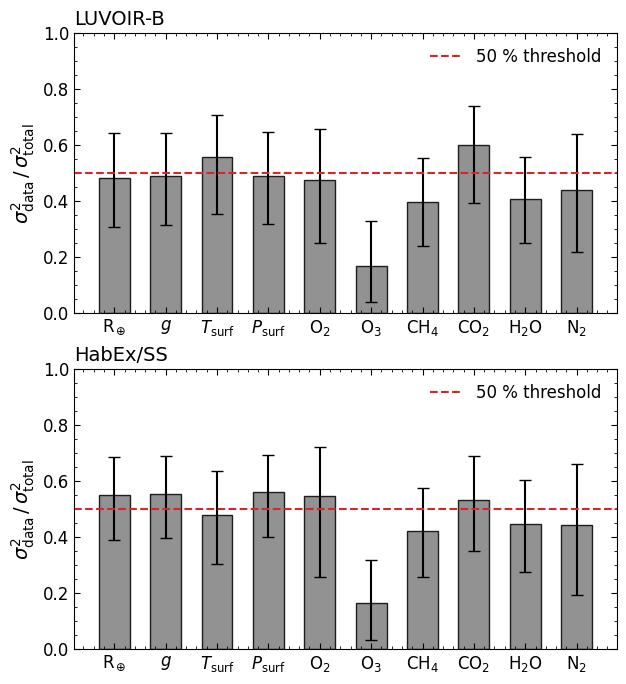

In [12]:
# Figure 4: Fraction of total variance due to data uncertainty
fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharey=True)
x_pos = np.arange(N_PARAMS)

for ax, tel_lbl, std_d, std_t in zip(
    axes,
    ["LUVOIR-B", "HabEx/SS"],
    [std_data_LU, std_data_HB],
    [total_std_LU, total_std_HB],
):

    # Per-sample fraction of variance due to data uncertainty
    # Avoid division by zero
    var_d = std_d**2
    var_t = std_t**2
    with np.errstate(divide="ignore", invalid="ignore"):
        frac = np.where(var_t > 0, var_d / var_t, np.nan)

    med_frac = np.nanmedian(frac, axis=0)
    q25_frac = np.nanpercentile(frac, 25, axis=0)
    q75_frac = np.nanpercentile(frac, 75, axis=0)

    ax.bar(
        x_pos,
        med_frac,
        0.6,
        color="tab:gray",
        alpha=0.85,
        edgecolor="k",
    )
    ax.errorbar(
        x_pos,
        med_frac,
        yerr=[med_frac - q25_frac, q75_frac - med_frac],
        fmt="none",
        color="k",
        capsize=4,
    )

    ax.axhline(0.5, linestyle="--", color="tab:red", label="50 % threshold")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(PARAM_LABELS)
    ax.set_ylabel(r"$\sigma^2_{\rm data}\,/\,\sigma^2_{\rm total}$")
    ax.set_ylim(0, 1)
    ax.set_title(tel_lbl, loc="left")
    ax.legend()

# plt.savefig("../images/data_uncertainty_fraction.pdf", dpi=200, bbox_inches="tight")
plt.show()

# Figure 6

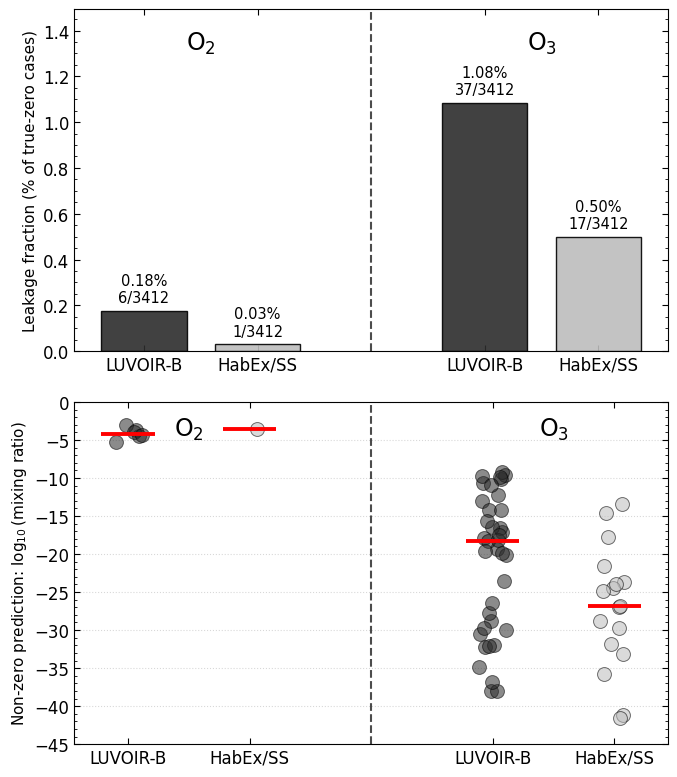

In [13]:
# Total number of true-zero Archean cases per group
N_null = 3412

# Counts of non-zero leaks
n_leak = {
    ("O2", "LUVOIR-B"): 6,
    ("O2", "HabEx/SS"): 1,
    ("O3", "LUVOIR-B"): 37,
    ("O3", "HabEx/SS"): 17,
}

# Arrays of non-zero leaks only, in physical units
leaks = {
    ("O2", "LUVOIR-B"): get_leaks(results_df_LUVOIR, "O2"),
    ("O2", "HabEx/SS"): get_leaks(results_df_HABEX, "O2"),
    ("O3", "LUVOIR-B"): get_leaks(results_df_LUVOIR, "O3"),
    ("O3", "HabEx/SS"): get_leaks(results_df_HABEX, "O3"),
}

# plotting order and positions
groups = [
    ("O2", "LUVOIR-B"),
    ("O2", "HabEx/SS"),
    ("O3", "LUVOIR-B"),
    ("O3", "HabEx/SS"),
]
xpos = [0, 1, 3, 4]
xticklabels = ["LUVOIR-B", "HabEx/SS", "LUVOIR-B", "HabEx/SS"]

# grayscale palette:
# darker = LUVOIR-B, lighter = HabEx/SS
colors = {
    ("O2", "LUVOIR-B"): "#2C2C2C",
    ("O2", "HabEx/SS"): "#BDBDBD",
    ("O3", "LUVOIR-B"): "#2C2C2C",
    ("O3", "HabEx/SS"): "#BDBDBD",
}

# --------------------------------------------------
# FIGURE
# --------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8))

# ==================================================
# PANEL 1: leakage frequency
# ==================================================
fractions = [100.0 * n_leak[g] / N_null for g in groups]

bars = ax1.bar(
    xpos,
    fractions,
    width=0.75,
    color=[colors[g] for g in groups],
    edgecolor="black",
    linewidth=1.0,
    alpha=0.9,
    zorder=3,
)

ax1.set_ylabel("Leakage fraction (% of true-zero cases)", fontsize=11)
ax1.set_xticks(xpos)
ax1.set_xticklabels(xticklabels, fontsize=12)
ax1.set_ylim(0, max(fractions) * 1.35 + 0.03)

# annotate percentages and counts
for x, g, frac in zip(xpos, groups, fractions):
    count = n_leak[g]
    ax1.text(
        x,
        frac + 0.025,
        f"{frac:.2f}%\n{count}/{N_null}",
        ha="center",
        va="bottom",
        fontsize=10.5,
    )

# species labels
ymax1 = ax1.get_ylim()[1]
ax1.text(0.5, ymax1 * 0.94, r"O$_2$", ha="center", va="top", fontsize=17)
ax1.text(3.5, ymax1 * 0.94, r"O$_3$", ha="center", va="top", fontsize=17)

# separator
ax1.axvline(2, color="black", linestyle="--", linewidth=1.5, alpha=0.7)

# ==================================================
# PANEL 2: conditional amplitude distribution
# ==================================================
rng = np.random.default_rng(42)

for x, g in zip(xpos, groups):
    y = np.asarray(leaks[g], dtype=float)
    if len(y) == 0:
        continue

    y_log = np.log10(y)

    jitter = rng.uniform(-0.12, 0.12, size=len(y))
    ax2.scatter(
        np.full(len(y), x) + jitter,
        y_log,
        s=100,
        color=colors[g],
        edgecolor="black",
        linewidth=0.7,
        alpha=0.55,
        zorder=3,
    )

    med = np.median(y_log)
    ax2.hlines(med, x - 0.22, x + 0.22, color="red", linewidth=2.8, zorder=4)

ax2.set_ylabel(r"Non-zero prediction: $\log_{10}(\mathrm{mixing\ ratio})$", fontsize=11)
ax2.set_xticks(xpos)
ax2.set_xticklabels(xticklabels, fontsize=12)
ax2.set_ylim(-45, 0)

ax2.grid(
    axis="y",
    which="major",
    linestyle=":",
    linewidth=0.8,
    color="gray",
    alpha=0.30,
    zorder=1,
)

ax2.text(0.5, -1.8, r"O$_2$", ha="center", va="top", fontsize=17)
ax2.text(3.5, -1.8, r"O$_3$", ha="center", va="top", fontsize=17)

ax2.axvline(2, color="black", linestyle="--", linewidth=1.5, alpha=0.7)

# cosmetic tweaks
for ax in (ax1, ax2):
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=12,
        direction="in",
        top=True,
        right=True,
    )
    ax.minorticks_on()

    # remove only the minor ticks from x-axis
    ax.tick_params(axis="x", which="minor", bottom=False, top=False)

plt.tight_layout()
plt.savefig("../images/exactly_zeros.pdf", dpi=150, bbox_inches="tight")
plt.show()

# Figure 8

In [27]:
def plot_projected_ig_ready(data, figsize=(7, 6), smooth_window=5):
    eras = ["modern", "proterozoic", "archean"]
    labels = ["Modern", "Proterozoic", "Archean"]
    colors = ["tab:blue", "tab:orange", "tab:green"]

    inst_keys = ["LUVOUIR-B", "HABEX-SS"]
    titles = ["LUVOIR-B", "HabEx/SS"]

    boundaries = {
        "LUVOUIR-B": [uv_b[-1], vis_b[-1]],
        "HABEX-SS": [uv_ss[-1], vis_ss[-1]],
    }

    ymax = 0.0
    for inst in inst_keys:
        for era in eras:
            y = np.asarray(data[inst]["ig_stats"][era]["projected_score"])
            ymax = max(ymax, y.max())
    ymax *= 1.10

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharey=True)

    for ax, inst, title in zip(axes, inst_keys, titles):
        wave = np.asarray(data[inst]["wave"])
        xmin, xmax = wave.min(), wave.max()

        b1, b2 = boundaries[inst]

        ax.axvline(b1, color="0.25", ls="--", lw=1.2, zorder=1)
        ax.axvline(b2, color="0.25", ls="--", lw=1.2, zorder=1)

        ytext = ymax * 0.96
        ax.text((xmin + b1) / 2, ytext, "UV", ha="center", va="top", fontsize=11)
        ax.text((b1 + b2) / 2, ytext, "VIS", ha="center", va="top", fontsize=11)
        ax.text((b2 + xmax) / 2, ytext, "NIR", ha="center", va="top", fontsize=11)

        for era, label, color in zip(eras, labels, colors):
            y = np.asarray(data[inst]["ig_stats"][era]["projected_score"])
            y_smooth = moving_average(y, window=smooth_window)

            ax.plot(wave, y, color=color, lw=0.9, alpha=0.25, zorder=2)
            ax.plot(wave, y_smooth, color=color, lw=2.0, label=label, zorder=3)

        ax.set_title(title, loc="left")
        ax.set_xlim(xmin, 2)
        ax.set_ylim(0, ymax)
        ax.set_ylabel("Normalized attribution score")
        ax.tick_params(direction="in", top=True, right=True)
        ax.minorticks_on()

    axes[-1].set_xlabel(r"Wavelength [$\mu$m]")

    handles, leg_labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        leg_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98),
        ncol=3,
        frameon=False,
    )

    fig.subplots_adjust(
        top=0.90,
        hspace=0.30,
    )

    return fig, axes

In [20]:
data = np.load("../data/bootstrap/ig_stats_2.npy", allow_pickle=True).item()

For each era:

`mean_signed`

This is what the current heatmap is maede of:
$$
\left\langle \mathrm{IG}_{n,k}(\lambda) \right\rangle_n
$$

`mean_abs`

This is:
$$
\left\langle |\mathrm{IG}_{n,k}(\lambda)| \right\rangle_n
$$

`mean_abs_norm`

This is the rigorous per-output normalized quantity:
$$
\left\langle
\frac{|\mathrm{IG}*{n,k}(\lambda)|}
{\sum*{\lambda'} |\mathrm{IG}_{n,k}(\lambda')|}
\right\rangle_n
$$

Each output row sums to about 1.

`projected_score`

This is the final 1D wavelength-priority curve:
$$
S(\lambda) =
\frac{1}{K}
\sum_k
\left\langle
\frac{|\mathrm{IG}*{n,k}(\lambda)|}
{\sum*{\lambda'} |\mathrm{IG}_{n,k}(\lambda')|}
\right\rangle_n
$$

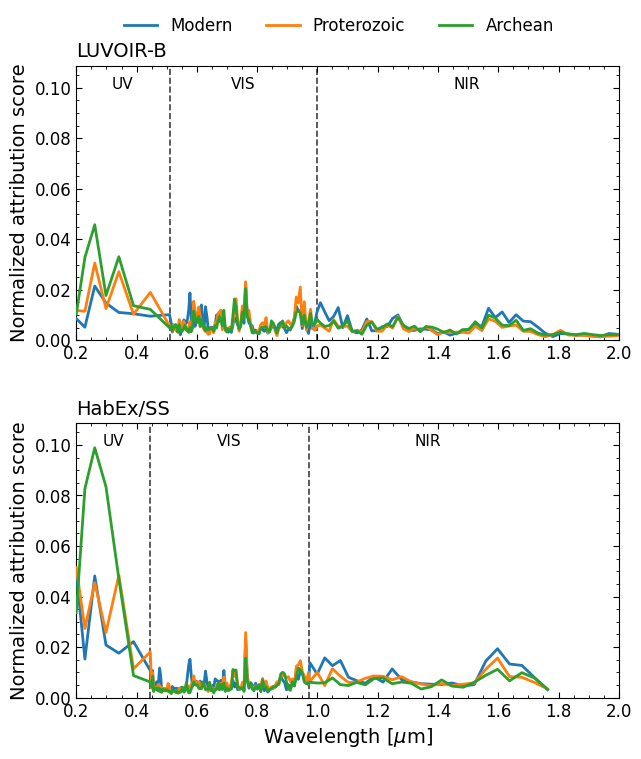

In [28]:
fig, axes = plot_projected_ig_ready(data, smooth_window=1, figsize=(7, 8))
plt.savefig("../images/ig_projected.pdf", dpi=300, bbox_inches="tight")
plt.show()

Trying different smooth window:

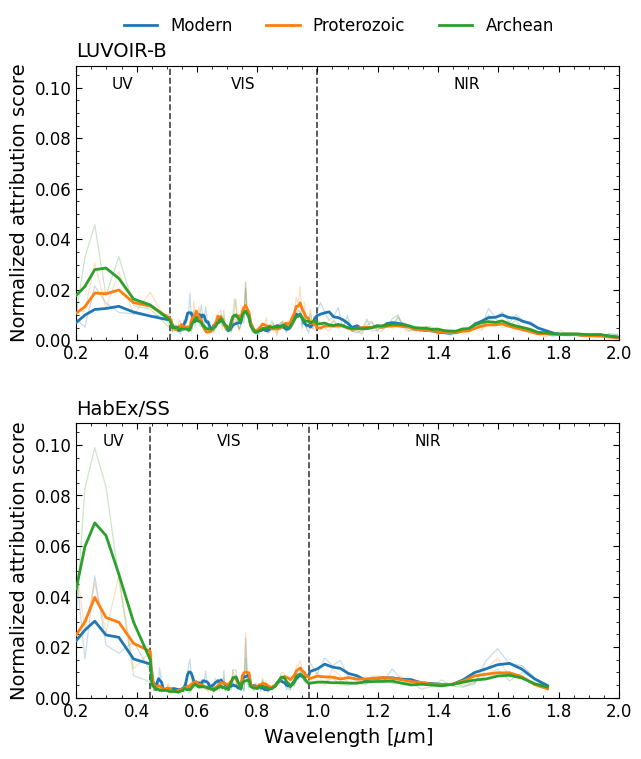

In [30]:
fig, axes = plot_projected_ig_ready(data, smooth_window=5, figsize=(7, 8))
plt.savefig("../images/ig_projected.pdf", dpi=300, bbox_inches="tight")
plt.show()